Ejemplo del libro de Ciaburro: https://github.com/PacktPublishing/Hands-On-Simulation-Modeling-with-Python-Second-Edition

In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.mixture import GaussianMixture
import pandas as pd

In [2]:
mean_1=25
st_1=9
mean_2=50
st_2=5

n_dist_1 = np.random.normal(loc=mean_1, scale=st_1, size=3000)
n_dist_2 = np.random.normal(loc=mean_2, scale=st_2, size=7000)

dist_merged = np.hstack((n_dist_1, n_dist_2))

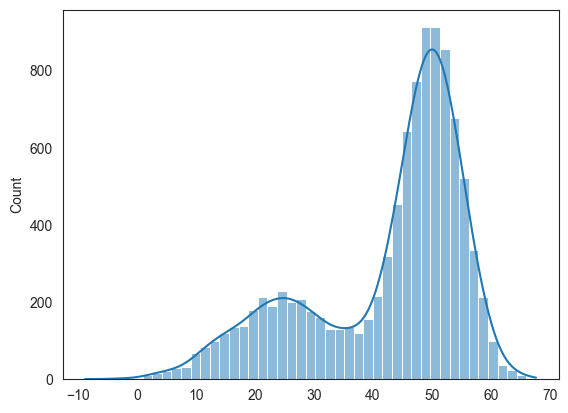

In [3]:
sns.set_style("white")
sns.histplot(data=dist_merged, kde=True)
plt.show()

In [4]:
dist_merged_res = dist_merged.reshape((len(dist_merged), 1))
gm_model = GaussianMixture(n_components=2, init_params='kmeans')
gm_model.fit(dist_merged_res)

print(f"Initial distribution means = {mean_1,mean_2}")
print(f"Initial distribution standard deviation = {st_1,st_2}")

print(f"GM_model distribution means = {gm_model.means_}")
print(f"GM_model distribution standard deviation = {np.sqrt(gm_model.covariances_)}")

Initial distribution means = (25, 50)
Initial distribution standard deviation = (9, 5)
GM_model distribution means = [[24.13316654]
 [49.88021444]]
GM_model distribution standard deviation = [[[8.76007654]]

 [[5.058694  ]]]


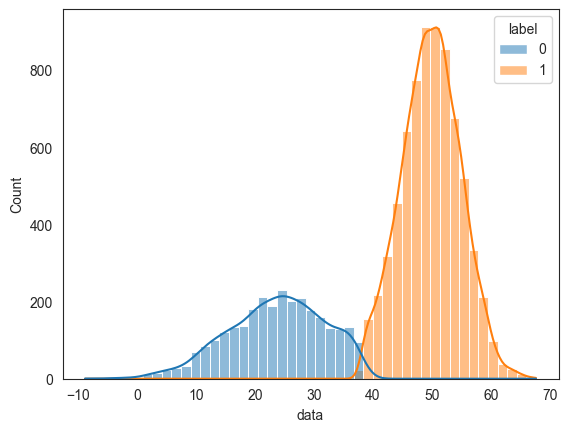

In [6]:
dist_labels = gm_model.predict(dist_merged_res)

sns.set_style("white")
data_pred=pd.DataFrame({'data':dist_merged, 'label':dist_labels})
sns.histplot(data = data_pred, x = "data", kde = True, hue = "label")
plt.show()

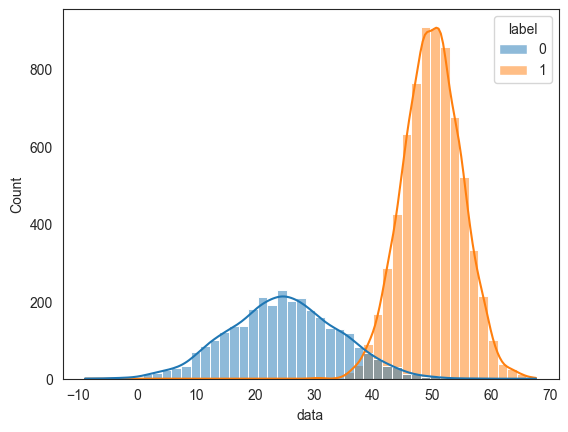

In [7]:
label_0 = np.zeros(3000, dtype=int)
label_1 = np.ones(7000, dtype=int)
labels_merged = np.hstack((label_0, label_1))
data_init=pd.DataFrame({'data':dist_merged, 'label':labels_merged})

sns.set_style("white")
sns.histplot(data = data_init, x = "data", kde = True, hue = "label")
plt.show()